# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** ☑ Standard Analysis ☐ Research-Oriented

**Group members:**  
- Christian-Vlad Vladutu 
- Daniel Langdal Jensen
- Victor Bakkestrøm Poulsen

**Dataset:**  Oracle's Elixir League of Legends esports stats https://oracleselixir.com/tools/downloads (currently 2025 only)

**Initial task description (Module 1 perspective):** Clustering similar player performances, matches, players and teams. Finding outlier players and teams. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

### Load data

In [ ]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir.csv'
data: pd.DataFrame = pd.read_csv(data_path)
#data = data.iloc[:int(len(data)*0.11 / 12) * 12] # 10% of data for testing to make code run faster - must be divisible by 12 since each match has 12 rows
data_len = int(len(data) * 10 / 12)

C:\Users\victo\AppData\Local\Temp\ipykernel_33352\866007119.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data: pd.DataFrame = pd.read_csv(data_path)


### Duplicating data and removing surplus rows

The data consists of rows of match statistics for specific players. 

Since each match has 2 teams of 5 players, you would expect 10 rows for each match. It turns out that there are 12 rows for each match because there are 2 extra rows that contain information about the team as a whole, rather than the players. 

Since we want to analyze the players, we take the teamwide information contained in these 2 rows (which is simply missing information in the player rows) and duplicate it to the player rows of those teams in the places that the players are missing data (if present in the team data). 

In [3]:
for matchid in tqdm(data["gameid"].unique()):
    game = data[data["gameid"] == matchid]
    teams = game["teamid"].unique()

    for teamid in teams:
        team = game[game["teamid"] == teamid]

        players = team[team["position"] != "team"]
        team_stats = team[team["position"] == "team"]

        # fill missing values in players with team stats if available
        for column in data.columns:
            if players[column].isnull().any():
                data.loc[players.index, column] = team_stats[column].item()

  0%|          | 0/10053 [00:00<?, ?it/s]

skip running above cell by loading the full imputated data

In [2]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)
print(f"matches: {int(data_len/10)}, made up of {data_len} player performances")
print(f"number of columns: {data.shape[1]}")
print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")

C:\Users\victor\AppData\Local\Temp\ipykernel_15540\4168379563.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)


matches: 10053, made up of 100530 player performances
number of columns: 165
percentage categorical variables: 13.94%


Text(0.5, 1.0, 'percentage of missing values by column')

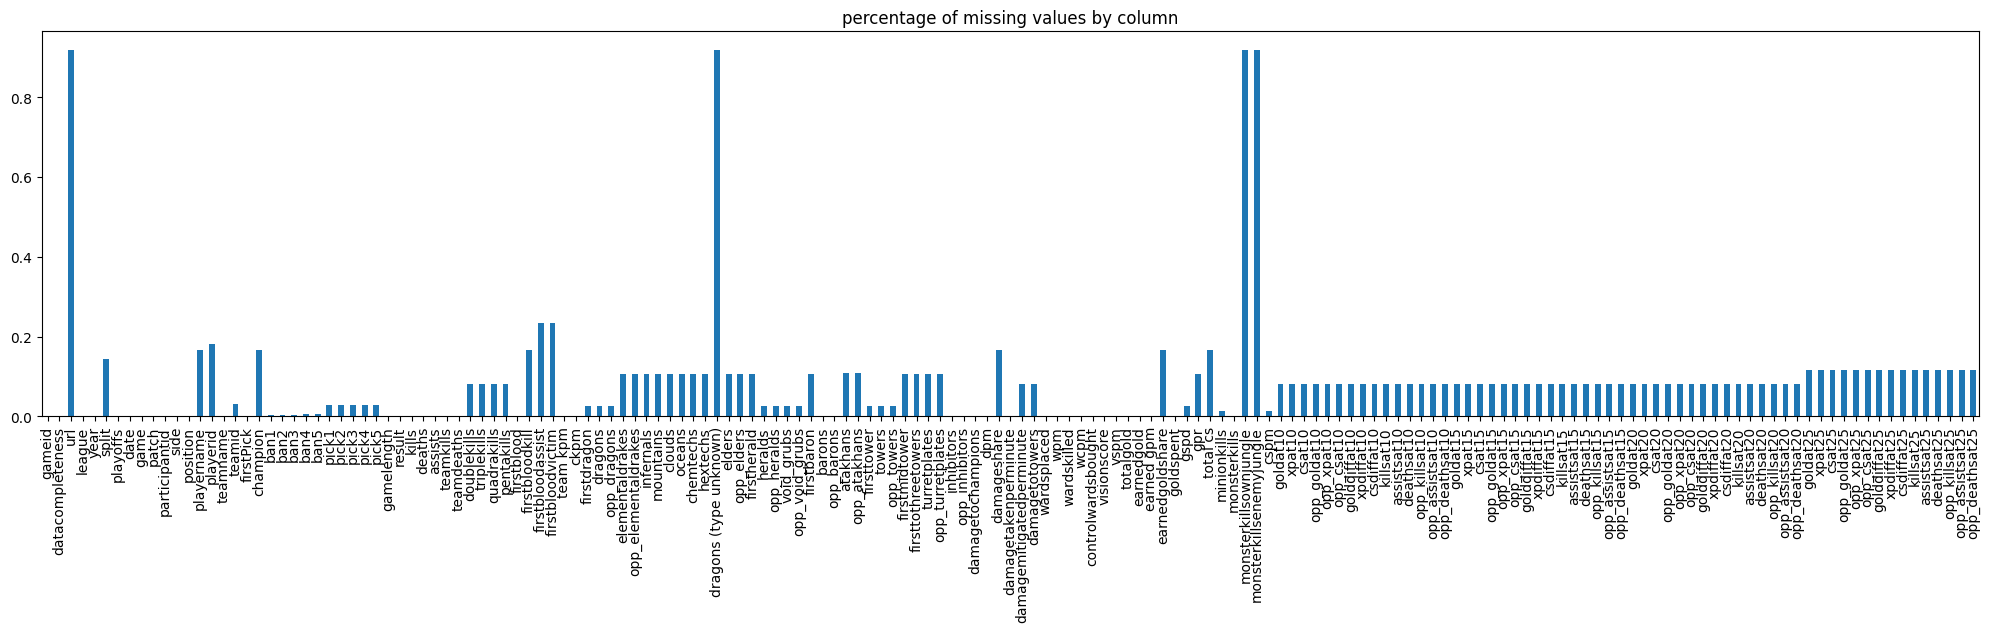

In [3]:
data.isnull().mean().plot(kind='bar', figsize=(25, 5))
plt.title('percentage of missing values by column')

In [ ]:
#data.to_csv("2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv")

We then drop all rows that only contain teamwide statistics, as we are currently interested in the player performances

In [4]:
data = data.drop(data[data["position"] == "team"].index) 

### Clean data for missing data and unrelated columns

Currently the data is full of missing values as can be seen on the missing value plot below, so we remove the the columns that have many missing values and then the rows that have many missing values. 

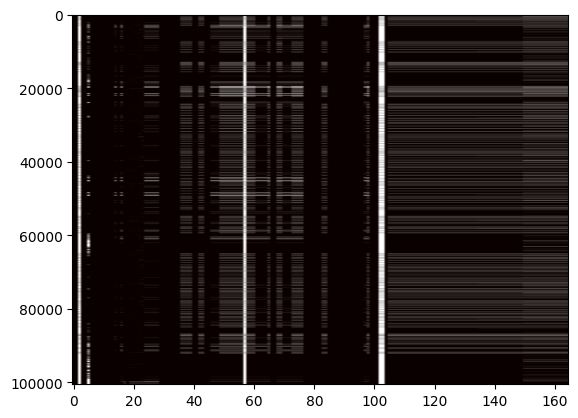

In [5]:
plt.imshow(data.isnull(), cmap='hot', aspect='auto')
plt.show()

In [6]:
# drop columns with more than a given percentage of missing values
missing_value_column_percentage_threshold = 0.20
missing_values = data.isnull().sum()
missing_value_columns = missing_values[missing_values > len(data) * missing_value_column_percentage_threshold].index
data = data.drop(columns=missing_value_columns)

# drop 10-rows (matches) with more than a given percentage of missing values
missing_value_row_percentage_threshold = 0
z = data.isnull().sum(axis=1)
gameids = data[z > len(data.columns) * missing_value_row_percentage_threshold]["gameid"].unique()

data = data.drop(data[data["gameid"].isin(gameids)].index)

The remaining data no longer contains a large amount of missing data as can be seen on the graph below, and still has 

In [7]:
100 * len(data) / data_len

71.58062269969163

% of the data rows, which represents 

In [8]:
len(data) / 10

7196.0

matches

### Modelling categorical variables as multivariate bernoulli variables (one-hot encoding)

In [9]:
# drop irrelevant columns
data_pure = data.drop(columns=["gameid", "split", "side", "datacompleteness", "league", "year", "playoffs", "date", "game", "patch", "participantid", "playername", "playerid", "teamname", "teamid"])

In [10]:
# convert categorical columns to one-hot encoding
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
X.shape

(71960, 1829)

This gives us a 1829-dimensional vector for each player-performance. Because of the curse of dimensionality this is too much to expect good results from, therefore we engineer a better vector by only keeping dimensions that are crucial for differentiating player performances. 

### Normalize data and calculate covariance and correlation matrix

In [11]:
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=0)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

###  Clustering of known quantity

Can we make a clustering of player performances that clusters each player performance into one of the 5 league of legends roles (Top / Jungle / Mid / Bottom / Support)?

We use k-means clustering with $k=5$. 

We need to remove the one-hot encoded player role ("position" column) from the data, as this is what we are hoping to determine with our clustering.

In [12]:
position_indexes = np.where(("position_top" == data_numeric.columns) | ("position_jng" == data_numeric.columns) | ("position_mid" == data_numeric.columns) | ("position_bot" == data_numeric.columns) | ("position_sup" == data_numeric.columns))
X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

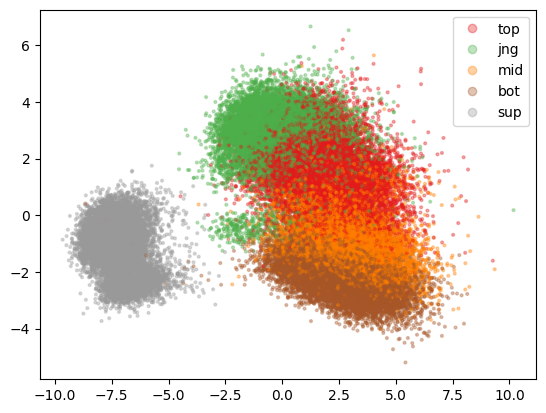

In [41]:
# plot pca with position as color
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat_no_position)
X_pca = pca.transform(X_hat_no_position)
z = {"top": 0, "jng": 1, "mid": 2, "bot": 3, "sup": 4}
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data_pure["position"].apply(lambda x: z[x]), cmap="Set1", s=4, alpha=0.35)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()

In [14]:
clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(data_pure["position"].iloc[np.where(clustering.labels_ == i)[0]].value_counts())
    print("")

Cluster 0:
position
mid    143
top    129
jng    129
bot    129
sup     17
Name: count, dtype: int64

Cluster 1:
position
top    23
jng    23
mid    23
bot    23
sup    23
Name: count, dtype: int64

Cluster 2:
position
sup    14264
bot        8
jng        1
Name: count, dtype: int64

Cluster 3:
position
top    73
jng    73
mid    73
bot    73
sup    73
Name: count, dtype: int64

Cluster 4:
position
top    14167
jng    14166
bot    14159
mid    14153
sup       15
Name: count, dtype: int64



We can see that we can easily separate support from the rest, but the other clusters are mixed and don't single out specific roles. While our clustering approach isn't perfect (we can see on the PCA plot that we should probably be able to cluster jungle well currently), we can still engineer our data much better. One reason this could be happening is due to the curse of dimensionality, we have 1800 dimensions and most of them are not important for clustering the points but having them increases the difficulty of the problem due to the curse of dimensionality. Our next approach is therefore to alleviate this by reducing the amount of dimensions. 

# Reducing the amount of dimensions

We pick out columns we have manually determined to likely play a big impact in differentiating player performances. Furthermore, we reduce the picked champion column from a one-hot encoding that takes 172 dimensions to a champion tag column that takes around 10 dimensions but is not a one-hot encoding, to do this we reduce the official league of legends champion class tags, for example, the champion Alistar is tagged as "Support" and "Tank", meaning the support and tank columns will have value 1, and the other columns will have value 0.

In [24]:
most_relevant_columns = ['champion', 'kills', 'deaths', 'assists','damagetochampions', 'dpm', 'damageshare', 'damagetakenperminute', 'damagemitigatedperminute', 'damagetotowers', 'wardsplaced', 'visionscore', 'totalgold', 'minionkills', 'monsterkills', 'xpat10', 'csat10', 'goldat10', 'xpat15', 'csat15', 'goldat15', 'xpat20', 'csat20', 'goldat20', 'xpat25', 'csat25', 'goldat25']
data_pure = data[most_relevant_columns + ["position"]]
from utility import champion_class_transform
import importlib
import sys
importlib.reload(sys.modules["utility"])
data_pure = champion_class_transform(data_pure)
data_pure[["Tank", "Fighter", "Assassin", "Mage", "Marksman", "Support"]]

,Tank,Fighter,Assassin,Mage,Marksman,Support
0,1,1,0,0,0,0
1,1,0,0,0,0,1
2,0,0,0,1,0,1
3,0,0,0,0,1,0
4,1,0,0,0,0,1
...,...,...,...,...,...,...
118925,0,1,0,0,0,0
118926,1,1,0,0,0,0
118927,0,0,1,1,0,0
118928,0,0,0,0,1,0


In [ ]:
# convert categorical columns to one-hot encoding
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
print(X.shape)

X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=0)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

position_indexes = np.where(("position_top" == data_numeric.columns) | ("position_jng" == data_numeric.columns) | ("position_mid" == data_numeric.columns) | ("position_bot" == data_numeric.columns) | ("position_sup" == data_numeric.columns))
X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(data_pure["position"].iloc[np.where(clustering.labels_ == i)[0]].value_counts())
    print("")

(71960, 37)
Cluster 0:
position
sup    14375
bot       19
jng        7
top        2
mid        1
Name: count, dtype: int64


Cluster 1:
position
top    11919
mid     1708
bot       37
sup        8
jng        7
Name: count, dtype: int64


Cluster 2:
position
jng    13982
top       49
mid        6
bot        5
sup        2
Name: count, dtype: int64


Cluster 3:
position
mid    10282
top     1786
jng      361
bot      219
sup        3
Name: count, dtype: int64


Cluster 4:
position
bot    14112
mid     2395
top      636
jng       35
sup        4
Name: count, dtype: int64




Our clustering is much better now, and succeeds in separating the data into 5 clusters based on roles, with a little abiguity in top/mid/bot. We also do a PCA plot to visualize the clusters around roles: 

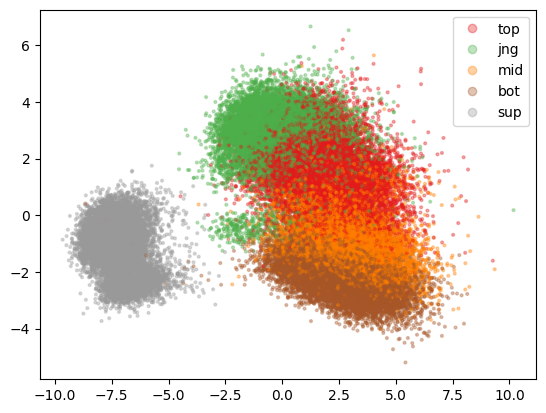

In [40]:
# plot pca with position as color
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat_no_position)
X_pca = pca.transform(X_hat_no_position)
z = {"top": 0, "jng": 1, "mid": 2, "bot": 3, "sup": 4}
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data_pure["position"].apply(lambda x: z[x]), cmap="Set1", s=4, alpha=0.35)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()

We can also do a T-sne plot, to see if our data can be better nonlinearly separated

In [219]:
X_embedded = sklearn.manifold.TSNE(n_components=2, verbose=0).fit_transform(X_hat_no_position)
z = {"top": 0, "jng": 1, "mid": 2, "bot": 3, "sup": 4}
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=data_pure["position"].apply(lambda x: z[x]), cmap="Set1", s=25, alpha=0.6)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()

KeyboardInterrupt: 

# Clustering of unknown quantity

## Clustering similar players

In order to cluster similar players we will take all of a players match performances and aggregate them into a single row by taing the mean, this aggregation will then represent that player.

In [92]:
data_pure = data[most_relevant_columns + ["position"]]
data_pure = champion_class_transform(data_pure)
data_numeric = pd.get_dummies(data_pure, dtype=float)


player_data = []
for player in tqdm(data["playerid"].unique()):
    player_indexes = data.loc[data["playerid"] == player].index

    player_data.append([player] + data_numeric.loc[player_indexes].mean().tolist())

player_data = pd.DataFrame(player_data, columns=["playerid"] + list(data_numeric.columns))
player_data

  0%|          | 0/2118 [00:00<?, ?it/s]

,playerid,kills,deaths,assists,damagetochampions,dpm,damageshare,damagetakenperminute,damagemitigatedperminute,damagetotowers,...,Marksman,Fighter,Tank,Assassin,Mage,position_bot,position_jng,position_mid,position_sup,position_top
0,oe:player:c659697694306de62d978569b84c344,3.032787,3.229508,6.573770,17642.983607,534.275141,0.199160,920.276048,1245.953148,3907.918033,...,0.000000,0.786885,0.672131,0.081967,0.311475,0.0,0.0,0.0,0.0,1.0
1,oe:player:dbdc61a1c41acedcbc7d399727155ac,3.440000,3.320000,8.880000,14966.580000,446.737598,0.170040,1123.416300,961.468164,1897.240000,...,0.060000,0.540000,0.640000,0.160000,0.140000,0.0,1.0,0.0,0.0,0.0
2,oe:player:694d028e62f4ea668b206ab752b6f94,4.901639,2.786885,7.508197,26986.622951,797.252087,0.295961,599.457866,434.158987,5073.590164,...,0.163934,0.098361,0.000000,0.278689,0.885246,0.0,0.0,1.0,0.0,0.0
3,oe:player:90704735ca9fc01f2244f23f6e5d635,5.548387,3.080645,6.274194,27119.467742,798.326889,0.284142,567.370126,376.748306,4971.629032,...,1.000000,0.000000,0.000000,0.016129,0.596774,1.0,0.0,0.0,0.0,0.0
4,oe:player:74f3f60a44ee916ecc257a5381be756,0.770492,3.901639,11.770492,6474.885246,193.323680,0.072830,646.139526,754.646284,1316.950820,...,0.000000,0.000000,0.737705,0.000000,0.131148,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2113,oe:player:c142a73b77f3c3df40777af2651f491,3.045455,4.409091,6.727273,18375.818182,614.637000,0.172104,1170.308259,1282.487986,3310.772727,...,0.000000,0.909091,0.727273,0.136364,0.000000,0.0,0.0,0.0,0.0,1.0
2114,oe:player:ada61b4241a68d672021ea46ab8bbf3,0.833333,3.750000,12.166667,6803.354167,222.529965,0.070088,581.836025,552.818027,442.750000,...,0.000000,0.000000,0.708333,0.000000,0.187500,0.0,0.0,0.0,1.0,0.0
2115,oe:player:768e1142ef81d6be29d5c000543bc28,3.200000,5.200000,5.400000,22980.400000,701.448720,0.220709,1049.988460,988.780800,6942.000000,...,0.000000,1.000000,0.200000,0.200000,0.200000,0.0,0.0,0.0,0.0,1.0
2116,oe:player:59d2a5ca2edb7a94fcf37170219e2c0,3.800000,4.200000,6.200000,14499.600000,440.315120,0.134900,1169.656360,1021.162460,1831.200000,...,0.000000,0.600000,0.200000,0.800000,0.000000,0.0,1.0,0.0,0.0,0.0


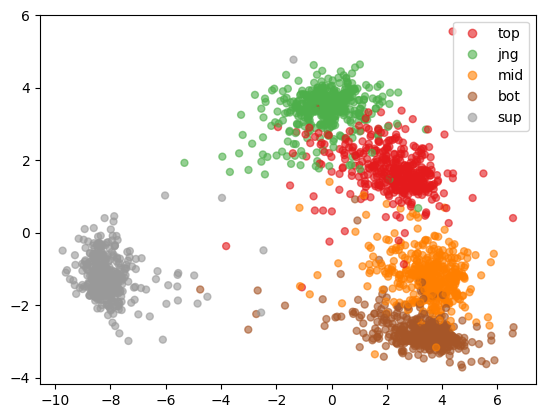

In [93]:
X = player_data.drop(columns=["playerid"]).to_numpy()
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=0)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

aligned_columns = player_data.columns[1:]
position_indexes = np.where(("position_top" == aligned_columns) | ("position_jng" == aligned_columns) | ("position_mid" == aligned_columns) | ("position_bot" == aligned_columns) | ("position_sup" == aligned_columns))

X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

# plot pca with position as color
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat_no_position)
X_pca = pca.transform(X_hat_no_position)
z = {"position_top": 0, "position_jng": 1, "position_mid": 2, "position_bot": 3, "position_sup": 4}
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=player_data[["position_top", "position_jng", "position_mid", "position_bot", "position_sup"]].idxmax(axis=1).map(z), cmap="Set1", s=25, alpha=0.6)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()

This approach gives us pretty well separable clusters of players by role. But by taking the mean we have losta great deal of information about the distribution of that players performances, so in order to recover this information and thus get more separable data we will add extra columns with information about the distributions of the columns for the player, such as variance and q-quantiles. 

In [96]:
data_pure = data[most_relevant_columns + ["position"]]
data_pure = champion_class_transform(data_pure)
data_numeric = pd.get_dummies(data_pure, dtype=float)


player_data = []
for player in tqdm(data["playerid"].unique()):
    player_indexes = data.loc[data["playerid"] == player].index
    if len(player_indexes) <= 2:
        continue  

    mean = data_numeric.loc[player_indexes].mean().tolist()
    variance = data_numeric.loc[player_indexes].var().tolist()
    # add quantile information
    quantile = data_numeric.loc[player_indexes].quantile([0.25, 0.5, 0.75]).values.flatten().tolist()

    player_data.append([player] + mean + variance + quantile)

player_data = pd.DataFrame(player_data, columns=["playerid"] + list(data_numeric.columns) + [f"{col}_var" for col in data_numeric.columns] + [f"{col}_{q}" for col in data_numeric.columns for q in [0.25, 0.5, 0.75]])
player_data

  0%|          | 0/2118 [00:00<?, ?it/s]

,playerid,kills,deaths,assists,damagetochampions,dpm,damageshare,damagetakenperminute,damagemitigatedperminute,damagetotowers,...,position_jng_0.75,position_mid_0.25,position_mid_0.5,position_mid_0.75,position_sup_0.25,position_sup_0.5,position_sup_0.75,position_top_0.25,position_top_0.5,position_top_0.75
0,oe:player:c659697694306de62d978569b84c344,3.032787,3.229508,6.573770,17642.983607,534.275141,0.199160,920.276048,1245.953148,3907.918033,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,oe:player:dbdc61a1c41acedcbc7d399727155ac,3.440000,3.320000,8.880000,14966.580000,446.737598,0.170040,1123.416300,961.468164,1897.240000,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,oe:player:694d028e62f4ea668b206ab752b6f94,4.901639,2.786885,7.508197,26986.622951,797.252087,0.295961,599.457866,434.158987,5073.590164,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
3,oe:player:90704735ca9fc01f2244f23f6e5d635,5.548387,3.080645,6.274194,27119.467742,798.326889,0.284142,567.370126,376.748306,4971.629032,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,oe:player:74f3f60a44ee916ecc257a5381be756,0.770492,3.901639,11.770492,6474.885246,193.323680,0.072830,646.139526,754.646284,1316.950820,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1958,oe:player:c142a73b77f3c3df40777af2651f491,3.045455,4.409091,6.727273,18375.818182,614.637000,0.172104,1170.308259,1282.487986,3310.772727,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1959,oe:player:ada61b4241a68d672021ea46ab8bbf3,0.833333,3.750000,12.166667,6803.354167,222.529965,0.070088,581.836025,552.818027,442.750000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1960,oe:player:768e1142ef81d6be29d5c000543bc28,3.200000,5.200000,5.400000,22980.400000,701.448720,0.220709,1049.988460,988.780800,6942.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1961,oe:player:59d2a5ca2edb7a94fcf37170219e2c0,3.800000,4.200000,6.200000,14499.600000,440.315120,0.134900,1169.656360,1021.162460,1831.200000,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


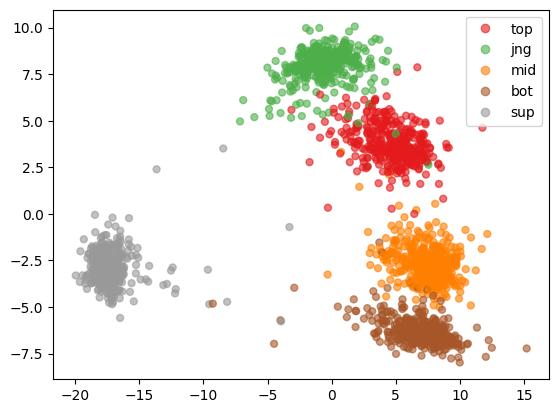

In [97]:
X = player_data.drop(columns=["playerid"]).to_numpy()
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=0)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

aligned_columns = player_data.columns[1:]
position_indexes = np.where(("position_top" == aligned_columns) | ("position_jng" == aligned_columns) | ("position_mid" == aligned_columns) | ("position_bot" == aligned_columns) | ("position_sup" == aligned_columns))
position_indexes_var = np.where(("position_top_var" == aligned_columns) | ("position_jng_var" == aligned_columns) | ("position_mid_var" == aligned_columns) | ("position_bot_var" == aligned_columns) | ("position_sup_var" == aligned_columns))

X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_hat_no_position = np.delete(X_hat, position_indexes_var, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

# plot pca with position as color
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat_no_position)
X_pca = pca.transform(X_hat_no_position)
z = {"position_top": 0, "position_jng": 1, "position_mid": 2, "position_bot": 3, "position_sup": 4}
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=player_data[["position_top", "position_jng", "position_mid", "position_bot", "position_sup"]].idxmax(axis=1).map(z), cmap="Set1", s=25, alpha=0.6)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()

This appears to make the clusters more dense and thus will likely make them easier to separate and run our clustering algorithms on. Let's run K-means:

In [108]:
clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(player_data.iloc[np.where(clustering.labels_ == i)[0]][["position_top", "position_jng", "position_mid", "position_bot", "position_sup"]].idxmax(axis=1).value_counts())
    print("")

Cluster 0:
position_top    381
position_mid      2
position_bot      1
position_sup      1
Name: count, dtype: int64

Cluster 1:
position_sup    401
position_bot      1
Name: count, dtype: int64

Cluster 2:
position_jng    403
position_bot      1
position_sup      1
Name: count, dtype: int64

Cluster 3:
position_bot    391
position_sup      1
position_jng      1
Name: count, dtype: int64

Cluster 4:
position_mid    378
Name: count, dtype: int64



We see that we manage to cluster players into their roles well. Let's look into clustering players within their roles, can we cluster top laners into passive players and aggressive players? 

  0%|          | 0/427 [00:00<?, ?it/s]

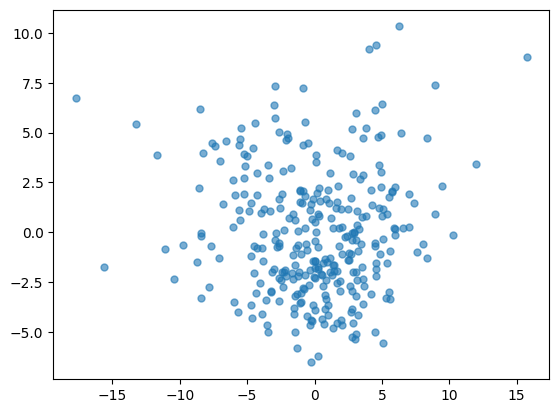

In [230]:
data_spec = data[data["position"] == "top"]

data_pure = data_spec[most_relevant_columns]
data_pure = champion_class_transform(data_pure)
data_numeric = pd.get_dummies(data_pure, dtype=float)

player_data = []
for player in tqdm(data_spec["playerid"].unique()):
    player_indexes = data_spec.loc[data_spec["playerid"] == player].index
    if len(player_indexes) <= 10:
        continue  

    mean = data_numeric.loc[player_indexes].mean().tolist()
    variance = data_numeric.loc[player_indexes].var().tolist()
    # add quantile information
    quantile = data_numeric.loc[player_indexes, data_numeric.columns[:5]].quantile([0.25, 0.5, 0.75]).values.T.flatten().tolist()

    player_data.append([player] + mean + variance + quantile)

player_data = pd.DataFrame(player_data, columns=["playerid"] + list(data_numeric.columns) + [f"{col}_var" for col in data_numeric.columns] + [f"{col}_{q}" for col in data_numeric.columns[:5] for q in [0.25, 0.5, 0.75]])

X = player_data.drop(columns=["playerid"]).to_numpy()
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=0)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

# plot pca 
pca = sklearn.decomposition.PCA(n_components=2).fit(X_normalized)
X_pca = pca.transform(X_normalized)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], s=25, alpha=0.6)
plt.show()


In [251]:
clustering = sklearn.cluster.KMeans(n_clusters=2).fit(X_normalized)
for i in range(2):
    print(f"Cluster {i}:")
    cluster_indices = np.where(clustering.labels_ == i)[0]
    print(len(cluster_indices))
    #with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    #    print(player_data.iloc[cluster_indices][player_data.columns[1:]].mean())
print("__")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    z = np.mean(player_data.iloc[np.where(clustering.labels_ == 0)[0]][player_data.columns[1:]], axis=0) - np.mean(player_data.iloc[np.where(clustering.labels_ == 1)[0]][player_data.columns[1:]], axis=0)
    print(z)


Cluster 0:
113
Cluster 1:
193
__
kills                          -8.929727e-01
deaths                          4.657569e-01
assists                        -4.771583e-01
damagetochampions              -3.416071e+03
dpm                            -9.869396e+01
damageshare                    -2.204880e-02
damagetakenperminute            2.499176e+01
damagemitigatedperminute        4.992267e+01
damagetotowers                 -1.490992e+03
wardsplaced                    -4.560072e-01
visionscore                    -2.609295e+00
totalgold                      -1.239503e+03
minionkills                    -1.975708e+01
monsterkills                   -2.725521e+00
xpat10                         -1.028051e+02
csat10                         -4.842956e+00
goldat10                       -1.241647e+02
xpat15                         -1.943621e+02
csat15                         -7.630209e+00
goldat15                       -2.461785e+02
xpat20                         -3.325407e+02
csat20                

c:\Users\victor\miniforge3\envs\nlp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


While the PCA is not great, when we cluster the top laners into two clusters using Kmeans we do find that one of the clusters has less kills, more damage taken, less gold overall than the other cluster. We can print their their tank / figher champion usage:

In [253]:
for i in range(2):
    print(f"Cluster {i}:")
    cluster_indices = np.where(clustering.labels_ == i)[0]
    print(player_data.iloc[cluster_indices][["Tank"]].mean())
    print(player_data.iloc[cluster_indices][["Fighter"]].mean())

Cluster 0:
Tank    0.530144
dtype: float64
Fighter    0.826987
dtype: float64
Cluster 1:
Tank    0.406145
dtype: float64
Fighter    0.89545
dtype: float64


And we find that one of the clusters tends to play more tanky defensive champions than the other. 

## Clustering similar matches
We are also interested in finding out if there is some pattern in the players perfomance, are there clear clusters showing potential different types of perfomance, EG a average performance, above average, below average. Yet unlike above there is no base truth that we can compare it to so it makes more sense to use clustering density clustering algorithmns like DBSCAN to try and find clusters of perfomances that are similar to eachother.

Ideally we want points that are somewhat close, but we want a relatively high MinPts since we are looking to find more generalized clusters rather than highly specific clusters

In [117]:
X_hat = X_normalized


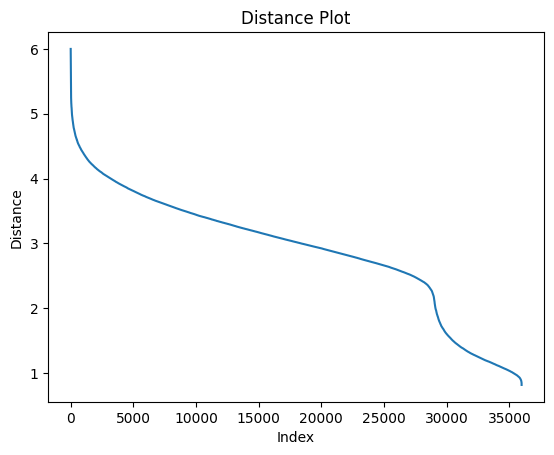

In [118]:
neighbors = 2*X_hat.shape[1]
nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_hat)
distances, indices = nbrs.kneighbors(X_hat)
distance_desc = sorted(distances[:,neighbors-1], reverse=True)
plt.plot(
    range(1, len(distance_desc) + 1),
    distance_desc
)

plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance Plot")

plt.show()

In [119]:
density_cluster = sklearn.cluster.DBSCAN(eps=2.5, min_samples = neighbors).fit(X_hat)
labels = np.unique(density_cluster.labels_)
labels

array([-1,  0,  1,  2,  3,  4])

We see using this method we only get one cluster, which is not entirely surprising considering the very high dimensionality of the data which is causing min pts to be very large based on the heuristic. To try to alleviate this we cna use PCA to reduce dimensionality to hopefully improve the results.

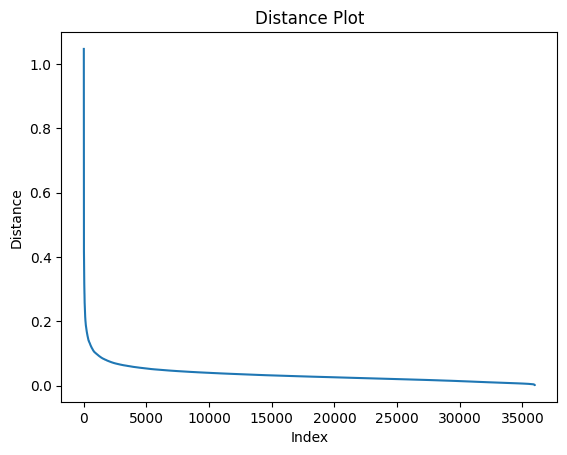

In [104]:
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat)
X_pca = pca.transform(X_hat)

neighbors = 2*X_pca.shape[1]
nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)
distance_desc = sorted(distances[:,neighbors-1], reverse=True)
plt.plot(
    range(1, len(distance_desc) + 1),
    distance_desc
)

plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance Plot")

plt.show()

In [110]:
density_cluster = sklearn.cluster.DBSCAN(eps=0.3, min_samples = neighbors).fit(X_pca)
unique_labels = np.unique(density_cluster.labels_)
unique_labels

array([-1,  0,  1,  2,  3,  4,  5])

Now we are seeing a few too many clusters due to the rule of thumb for min pts not really working well for this type of data, as we ideally want to group games fall into more broad clusters. So we will manually set min pts to 20.

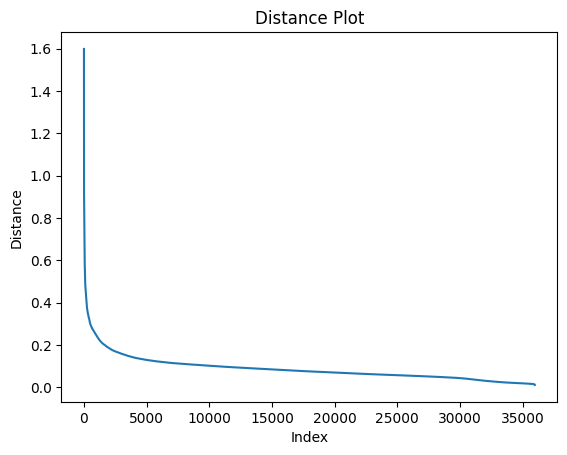

In [92]:
neighbors = 20
nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)
distance_desc = sorted(distances[:,neighbors-1], reverse=True)
plt.plot(
    range(1, len(distance_desc) + 1),
    distance_desc
)

plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance Plot")

plt.show()

In [93]:
density_cluster = sklearn.cluster.DBSCAN(eps=0.6, min_samples = neighbors).fit(X_pca)
unique_labels = np.unique(density_cluster.labels_)
labels = density_cluster.labels_
unique_labels

array([-1,  0,  1])

In [94]:
label_counts = np.unique(labels, return_counts=True)
label_counts

(array([-1,  0,  1]), array([   11, 28775,  7194]))

Now we are getting a more reasonable 3 clusters, though one cluster is highly represented 

In [105]:
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[density_cluster.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X_pca[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X_pca[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {len(unique_labels)-1}")
plt.show()

IndexError: index 9 is out of bounds for axis 0 with size 6

This can be read as that a vast perfomances being similar, though we should still try to investigate a bit further

We can try to use OPTICS instead since it is better suited for such high dimensional data